In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

X, y, true_coefficient = make_regression(n_samples=200, n_features=30, n_informative=10, noise=100, coef=True, random_state=5)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=5, train_size=60, test_size=140)

print(X_train.shape)
print(y_train.shape)

(60, 30)
(60,)


# Linear Regression
## Goal: Finds the linear relationship between features and target by minimizing the sum of squared errors.
### Simple: Make the total of (real value minus guess) squared very tiny.

In [3]:
from sklearn.linear_model import LinearRegression
linear_regression = LinearRegression().fit(X_train, y_train)
print("R^2 on training set: %f" % linear_regression.score(X_train, y_train))
print("R^2 on test set: %f" % linear_regression.score(X_test, y_test))

R^2 on training set: 0.878011
R^2 on test set: 0.216332


In [4]:
from sklearn.metrics import r2_score
print(r2_score(np.dot(X, true_coefficient), y))

0.5985284495875146


In [5]:
true_coefficient

array([ 0.        ,  0.        ,  2.12227127,  0.        ,  0.        ,
       49.25507875,  0.        ,  0.        ,  0.        , 15.07583458,
        0.        ,  0.        , 32.29058037,  0.        ,  0.        ,
        8.41487791,  0.        ,  0.        ,  0.        , 64.56924673,
        0.        ,  0.        ,  0.        , 70.85764943,  0.        ,
       34.28961765, 88.17735659,  0.        , 80.81291382,  0.        ])

In [6]:
np.argsort(true_coefficient)

array([ 0,  1,  3,  4,  7,  6, 10,  8, 14, 13, 11, 22, 20, 18, 17, 16, 29,
       21, 27, 24,  2, 15,  9, 12, 25,  5, 19, 23, 28, 26])

In [7]:
np.argsort(true_coefficient)[::-1]

array([26, 28, 23, 19,  5, 25, 12,  9, 15,  2, 24, 27, 21, 29, 16, 17, 18,
       20, 22, 11, 13, 14,  8, 10,  6,  7,  4,  3,  1,  0])

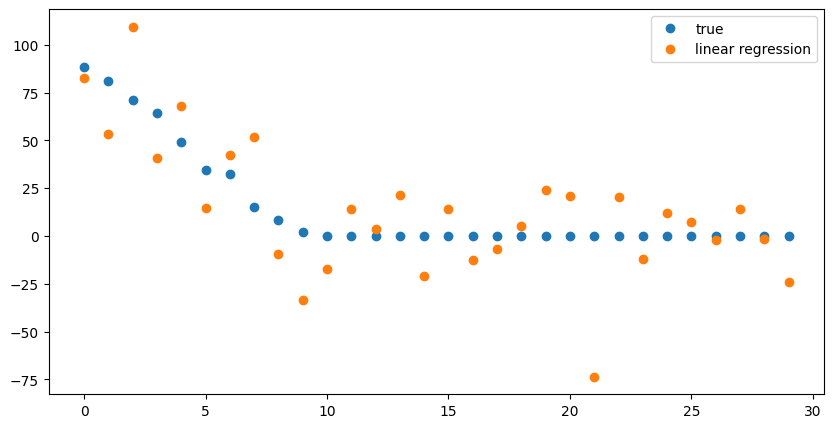

In [8]:
plt.figure(figsize=(10, 5))
coefficient_sorting = np.argsort(true_coefficient)[::-1]
plt.plot(true_coefficient[coefficient_sorting], 'o', label="true")
plt.plot(linear_regression.coef_[coefficient_sorting], 'o', label="linear regression")

plt.legend()
plt.show()

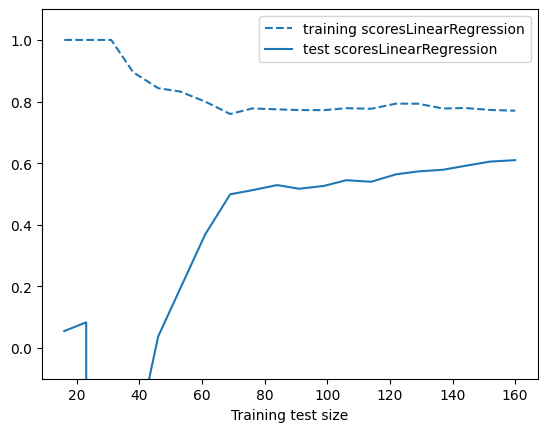

In [9]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(est, X, y):
    training_set_size, train_scores, test_scores = learning_curve(est, X, y, train_sizes=np.linspace(.1, 1, 20))
    estimator_name = est.__class__.__name__
    line = plt.plot(training_set_size, train_scores.mean(axis=1), '--', label="training scores" + estimator_name)
    plt.plot(training_set_size, test_scores.mean(axis=1), '-', label="test scores" + estimator_name, c=line[0].get_color())
    plt.xlabel('Training test size')
    plt.legend(loc='best')
    plt.ylim(-0.1, 1.1)

plt.figure()
plot_learning_curve(LinearRegression(), X, y)

# Ridge Regression (L2 penalty)
## Goal: Extends linear regression by adding a penalty on the squared magnitude of coefficients. Shrinks all coefficients toward zero but never exactly zero, reducing overfitting.

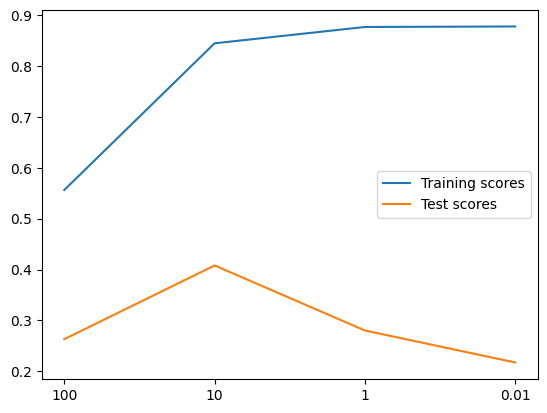

In [10]:
from sklearn.linear_model import Ridge
ridge_models = {}
training_scores = []
test_scores = []

for alpha in [100, 10, 1, 0.01]:
    ridge = Ridge(alpha=alpha).fit(X_train, y_train)
    training_scores.append(ridge.score(X_train, y_train))
    test_scores.append(ridge.score(X_test, y_test))
    ridge_models[alpha] = ridge
plt.figure()
plt.plot(training_scores, label="Training scores")
plt.plot(test_scores, label="Test scores")
plt.xticks(range(4), [100, 10, 1, 0.01])
plt.legend(loc='best')
plt.show()

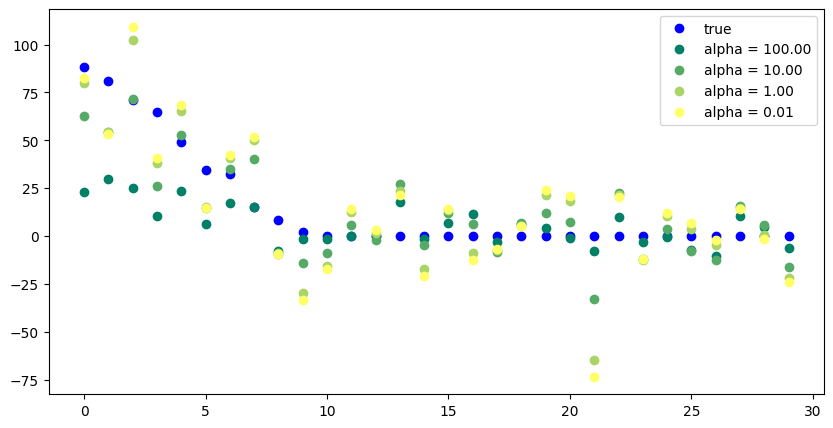

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(true_coefficient[coefficient_sorting], "o", label="true", c='b')

for i, alpha in enumerate([100, 10, 1, 0.01]):
    plt.plot(ridge_models[alpha].coef_[coefficient_sorting], "o", label="alpha = %.2f" % alpha, c=plt.cm.summer(i/3.))

plt.legend(loc='best')
plt.show()

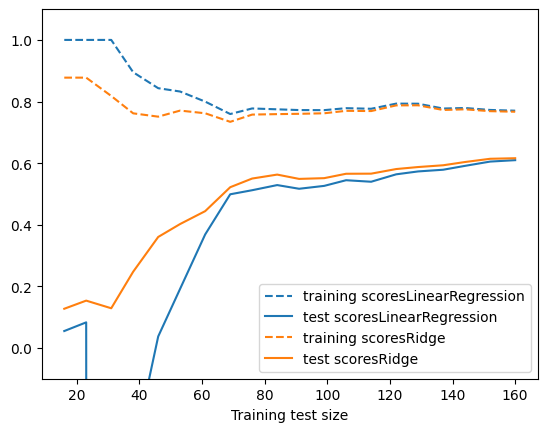

In [12]:
plt.figure()
plot_learning_curve(LinearRegression(), X, y)
plot_learning_curve(Ridge(alpha=10), X, y)

# Lasso (L1 penalty)
## Goal: Similar to Ridge, but uses a penalty that forces some coefficients to become exactly zero. Performs automatic feature selection and produces sparse models.

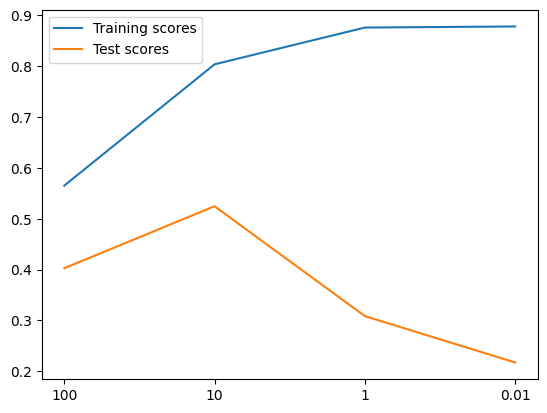

In [13]:
from sklearn.linear_model import Lasso
lasso_models = {}
training_scores = []
test_scores = []

for alpha in [30, 10, 1, 0.01]:
    lasso = Lasso(alpha=alpha).fit(X_train, y_train)
    training_scores.append(lasso.score(X_train, y_train))
    test_scores.append(lasso.score(X_test, y_test))
    lasso_models[alpha] = lasso
plt.figure()
plt.plot(training_scores, label="Training scores")
plt.plot(test_scores, label="Test scores")
plt.xticks(range(4), [100, 10, 1, 0.01])
plt.legend(loc='best')
plt.show()

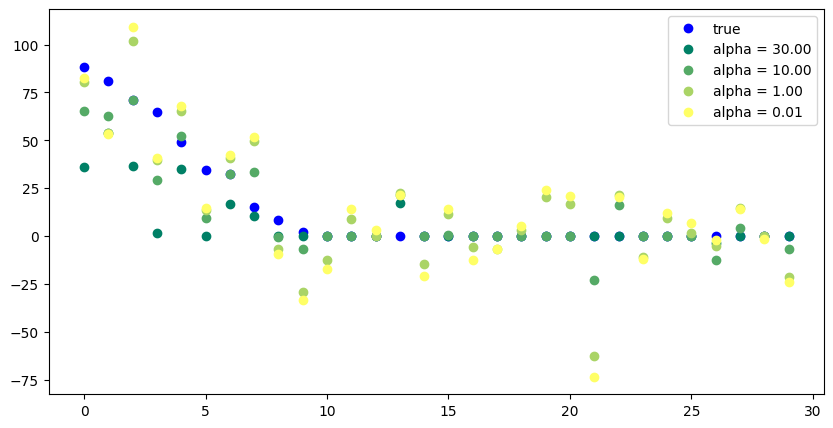

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(true_coefficient[coefficient_sorting], "o", label="true", c='b')

for i, alpha in enumerate([30, 10, 1, 0.01]):
    plt.plot(lasso_models[alpha].coef_[coefficient_sorting], "o", label="alpha = %.2f" % alpha, c=plt.cm.summer(i/3.))

plt.legend(loc='best')
plt.show()

C:\Users\aydin\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.054e+01, tolerance: 4.958e+01
  model = cd_fast.enet_coordinate_descent(


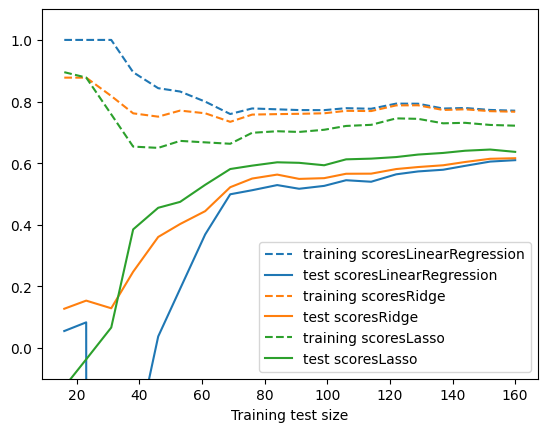

In [15]:
plt.figure()
plot_learning_curve(LinearRegression(), X, y)
plot_learning_curve(Ridge(alpha=10), X, y)
plot_learning_curve(Lasso(alpha=10), X, y)

# Linear models for classification

## Multi-class linear classification

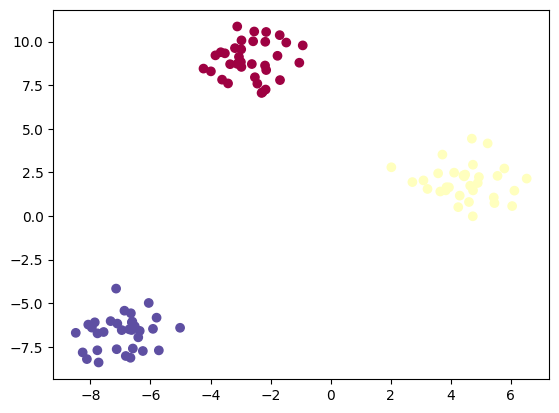

In [24]:
from sklearn.datasets import make_blobs

plt.figure()
X, y = make_blobs(random_state=42)
plt.scatter(X[:, 0], X[:, 1], c=plt.matplotlib.colormaps.get_cmap("Spectral")(y / 2.))

In [25]:
from sklearn.svm import LinearSVC

linear_svm = LinearSVC().fit(X, y)
print(linear_svm.coef_.shape)
print(linear_svm.intercept_)

(3, 2)
[-1.07745775  0.13139239 -0.08604962]


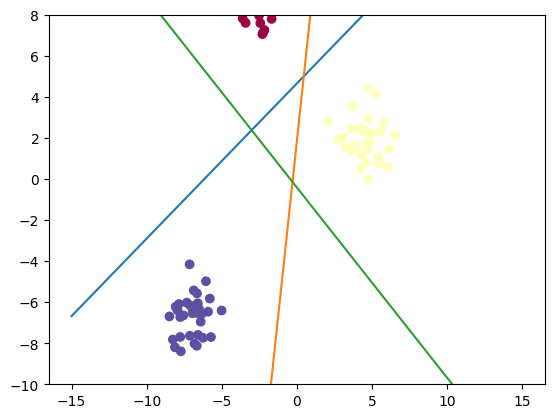

In [22]:
plt.scatter(X[:, 0], X[:, 1], c=plt.matplotlib.colormaps.get_cmap("Spectral")(y / 2.))
line = np.linspace(-15, 15)
for coef, intercept in zip(linear_svm.coef_, linear_svm.intercept_):
    plt.plot(line, -(line * coef[0] + intercept) / coef[1])
plt.ylim(-10, 15)
plt.ylim(-10, 8);